In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from pyBKT.models import Model
from sklearn.metrics import roc_auc_score

In [33]:
from pathlib import Path

base_path = Path().resolve().parent
file_path = base_path / "data" / "raw" / "Stellar_edu_MSD_ap_stats_unit1_class_dataset.xlsx"

In [34]:
student_obs = pd.read_excel(file_path, sheet_name="Student_Observations")
q_matrix = pd.read_excel(file_path, sheet_name="Q_Matrix_Binary")
kc_nodes = pd.read_excel(file_path, sheet_name="KC_Nodes")
kc_edges = pd.read_excel(file_path, sheet_name="KC_Edges")
overall_scores = pd.read_excel(file_path, sheet_name="Overall_Scores")


In [35]:
student_obs.head(2)

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,simulated_response,correct_answer_or_rubric,rubric_level
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.00000,1,0,C,E,NaN
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.00000,1,100,E,E,NaN


In [36]:
q_matrix.head(2)

,assignment_id,observation_id,item_type,source_question,primary_kc_id,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,KC.U1.04.variable_type_discrete_continuous,KC.U1.05.categorical_freq_relative,...,KC.U1.18.linear_transformations,KC.U1.19.z_score_compute_interpret,KC.U1.20.normal_model_appropriateness,KC.U1.21.empirical_rule_sd,KC.U1.22.normal_tail_interval_probability,KC.U1.23.inverse_normal_percentile,KC.U1.24.compare_standardized_values,KC.U1.25.percentile_quartile_interpretation,KC.U1.26.graph_construction_axes,KC.U1.27.sample_population_scope
0,HW1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HW1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
kc_nodes.head(2)

,kc_id,intro_class,kc_label,description,reporting_group,ap_skill_refs,difficulty_prior,mastery_observable,modeling_note
0,KC.U1.01.statistical_context,1,Statistical context and investigative question,"Recognize the study context, what is being inv...",Data foundations,1.A;2.A,0.25000,Item part can be scored for this KC using MCQ ...,Use as a latent skill/KC; official AP skills a...
1,KC.U1.02.observational_unit_variable,1,Observational unit and variable,Identify what object/person is being measured ...,Data foundations,2.A,0.30000,Item part can be scored for this KC using MCQ ...,Use as a latent skill/KC; official AP skills a...


In [38]:
kc_edges.head(2)

,edge_id,source_kc_id,target_kc_id,relation,official,confidence,evidence_note
0,E001,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,supports,False,0.80000,Context helps identify what is measured.
1,E002,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,prerequisite,False,0.90000,You classify the variable after identifying th...


In [39]:
overall_scores.head(2)

,student_id,display_name,performance_band,unit1_raw_score,unit1_max_score,unit1_percent,hw1_percent,hw2_percent,hw3_percent
0,S001,Student 01,Developing,39.50000,69,57.20000,57.10000,75.00000,39.60000
1,S002,Student 02,Advanced,52.00000,69,75.40000,66.70000,89.60000,68.80000


## Exploratory Data Analysis

In [74]:
kc_obs_counts = student_obs.groupby(['primary_kc_id', 'assignment_id'])[
    'observation_id'].count().reset_index().rename(columns={
        'primary_kc_id': 'kc_id',
        'observation_id': 'obs_count'
    })
kc_obs_counts

,kc_id,assignment_id,obs_count
0,KC.U1.02.observational_unit_variable,HW1,25
1,KC.U1.03.variable_type_cat_quant,HW1,50
2,KC.U1.04.variable_type_discrete_continuous,HW2,50
3,KC.U1.05.categorical_freq_relative,HW1,125
4,KC.U1.06.categorical_bar_pie_segmented,HW1,175
5,KC.U1.07.two_way_table_association,HW1,75
6,KC.U1.08.graph_choice_categorical,HW1,50
7,KC.U1.09.quantitative_display_reading,HW2,25
8,KC.U1.10.histogram_shape_features,HW2,75
9,KC.U1.11.describe_distribution_socs,HW3,25


In [75]:
kc_obs_counts = kc_obs_counts.merge(
    kc_nodes[['kc_id', 'kc_label']],
    on='kc_id'
)
kc_obs_counts = kc_obs_counts.sort_values(by='obs_count')

kc_obs_counts

,kc_id,assignment_id,obs_count,kc_label
0,KC.U1.02.observational_unit_variable,HW1,25,Observational unit and variable
24,KC.U1.25.percentile_quartile_interpretation,HW2,25,Percentiles and quartile interpretation
20,KC.U1.21.empirical_rule_sd,HW3,25,Empirical rule and standard deviation reasoning
17,KC.U1.18.linear_transformations,HW3,25,Linear transformations of data
25,KC.U1.26.graph_construction_axes,HW3,25,Construct graphs with correct axes and scale
9,KC.U1.11.describe_distribution_socs,HW3,25,Describe a quantitative distribution
7,KC.U1.09.quantitative_display_reading,HW2,25,Read quantitative displays
26,KC.U1.27.sample_population_scope,HW1,25,"Sample, population, and scope of generalization"
13,KC.U1.15.outlier_rule,HW2,50,1.5 × IQR outlier rule
1,KC.U1.03.variable_type_cat_quant,HW1,50,Categorical vs quantitative variable


In [76]:
len(kc_obs_counts.kc_id.unique())

26

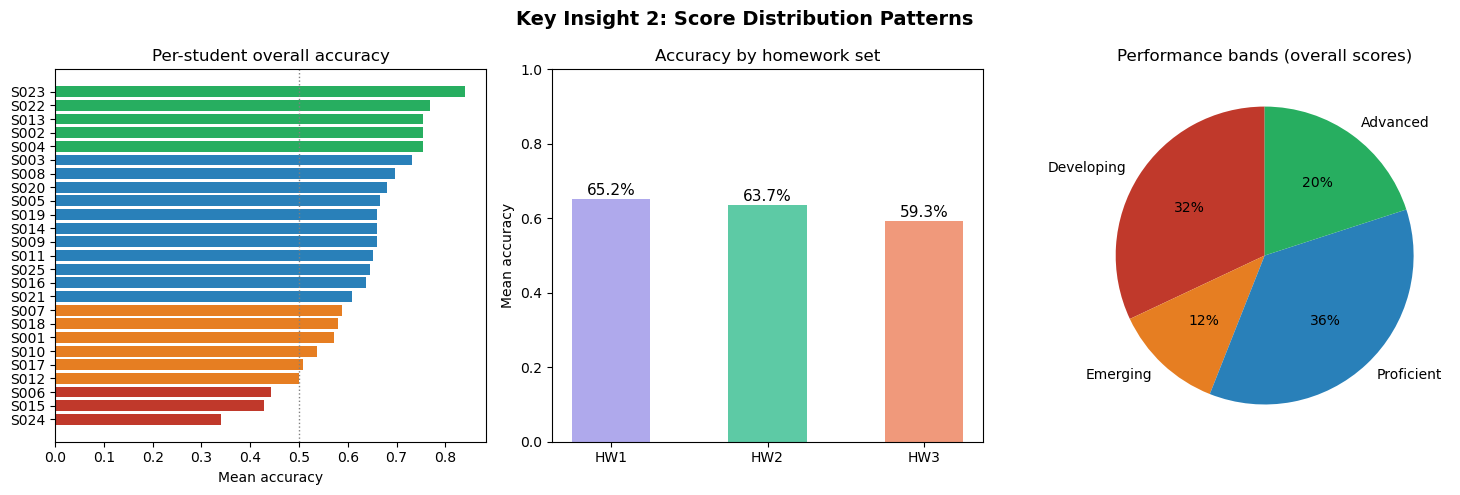

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Per-student score distribution
ax = axes[0]
stu_scores = student_obs.groupby('student_id')['score'].mean().sort_values()
band_colors = []
for v in stu_scores.values:
    if v < 0.5: band_colors.append('#C0392B')
    elif v < 0.6: band_colors.append('#E67E22')
    elif v < 0.75: band_colors.append('#2980B9')
    else: band_colors.append('#27AE60')
ax.barh(stu_scores.index, stu_scores.values, color=band_colors)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Mean accuracy')
ax.set_title('Per-student overall accuracy')

# 2. Score by HW set
ax = axes[1]
hw_acc = student_obs.groupby('assignment_id')['score'].mean()
hw_order = ['HW1','HW2','HW3']
vals = [hw_acc[h] for h in hw_order]
bars = ax.bar(hw_order, vals, color=['#AFA9EC','#5DCAA5','#F0997B'], width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('Accuracy by homework set')

# 3. Performance band pie
ax = axes[2]
band_counts = overall_scores['performance_band'].value_counts()
band_order = ['Developing','Emerging','Proficient','Advanced']
bcolors = ['#C0392B','#E67E22','#2980B9','#27AE60']
present = [b for b in band_order if b in band_counts.index]
pcolors = [bcolors[band_order.index(b)] for b in present]
ax.pie([band_counts[b] for b in present], labels=present, colors=pcolors,
       autopct='%1.0f%%', startangle=90)
ax.set_title('Performance bands (overall scores)')

plt.suptitle('Key Insight 2: Score Distribution Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## MODELLING

pyBKT needs a DataFrame with **exactly these column names**:

| Column | Type | Meaning |
|---|---|---|
| `user_id` | string or int | Who is the student? |
| `skill_name` | string | Which KC is being tested? |
| `correct` | 0 or 1 | Did they get it right? |
| `order_id` | int | What order did they answer their homework? (lower = earlier) |

In [42]:
# drop instances where the score is 0.5 (partially correct) since BKT only models binary outcomes

bkt_data = student_obs[student_obs['score'] != 0.5].copy()
bkt_data['correct'] = bkt_data['score'].astype(int)

# bkt_data['correct'] = (bkt_data['score'] == 1).astype(int)

# rename columns to match pyBKT's expected format and select only relevant columns
bkt_data = bkt_data.rename(columns={
    'student_id':     'user_id',
    'primary_kc_id':  'skill_name',
    'observation_id': 'order_id'
})[['user_id', 'skill_name', 'correct', 'order_id']]

In [43]:
bkt_data.head()

,user_id,skill_name,correct,order_id
0,S001,KC.U1.02.observational_unit_variable,0,HW1_PCA_Q01
1,S001,KC.U1.03.variable_type_cat_quant,1,HW1_PCA_Q02
2,S001,KC.U1.03.variable_type_cat_quant,0,HW1_PCA_Q03
3,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q04
4,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q05


In [44]:
bkt_data = bkt_data.sort_values(['user_id', 'order_id']).reset_index(drop=True)

bkt_data.head()

,user_id,skill_name,correct,order_id
0,S001,KC.U1.02.observational_unit_variable,0,HW1_PCA_Q01
1,S001,KC.U1.03.variable_type_cat_quant,1,HW1_PCA_Q02
2,S001,KC.U1.03.variable_type_cat_quant,0,HW1_PCA_Q03
3,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q04
4,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q05


In [51]:
bkt_data['user_id'].unique()

<StringArray>
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009',
 'S010', 'S011', 'S012', 'S013', 'S014', 'S015', 'S016', 'S017', 'S018',
 'S019', 'S020', 'S021', 'S022', 'S023', 'S024', 'S025']
Length: 25, dtype: str

In [53]:
bkt_data.loc[bkt_data['user_id'] == 'S002']

,user_id,skill_name,correct,order_id
68,S002,KC.U1.02.observational_unit_variable,1,HW1_PCA_Q01
69,S002,KC.U1.03.variable_type_cat_quant,0,HW1_PCA_Q02
70,S002,KC.U1.03.variable_type_cat_quant,1,HW1_PCA_Q03
71,S002,KC.U1.05.categorical_freq_relative,0,HW1_PCA_Q04
72,S002,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q05
...,...,...,...,...
130,S002,KC.U1.20.normal_model_appropriateness,1,HW3_SG1_Q86
131,S002,KC.U1.22.normal_tail_interval_probability,0,HW3_SG1_Q87
132,S002,KC.U1.23.inverse_normal_percentile,1,HW3_SG1_Q88
133,S002,KC.U1.23.inverse_normal_percentile,1,HW3_SG1_Q92


In [ ]:
# identify KCs with very few observations (<= 25) and exclude them from the BKT model
floor_kcs = kc_obs_counts[kc_obs_counts['obs_count'] <= 25]['kc_id'].tolist()

bkt_data_full = bkt_data.copy()

In [71]:
len(floor_kcs)

7

In [55]:
bkt_data = bkt_data[~bkt_data['skill_name'].isin(floor_kcs)].copy()

In [19]:
print(f"Total rows (all KCs):       {len(bkt_data_full):,}")
print(f"Rows after removing floors: {len(bkt_data):,}")
print(f"KCs included:               {bkt_data['skill_name'].nunique()}")
print(f"Students:                   {bkt_data['user_id'].nunique()}")
print(f"Correct rate:               {bkt_data['correct'].mean():.1%}")

Total rows (all KCs):       1,692
Rows after removing floors: 1,452
KCs included:               18
Students:                   25
Correct rate:               62.9%


In [56]:
# convert order id to numbers

# bkt_data['order_id'], order_mapping = pd.factorize(bkt_data['order_id'])
bkt_data['order_id'] = bkt_data.groupby('user_id').cumcount()


In [59]:
bkt_data.head(20)

,user_id,skill_name,correct,order_id
1,S001,KC.U1.03.variable_type_cat_quant,1,0
2,S001,KC.U1.03.variable_type_cat_quant,0,1
3,S001,KC.U1.05.categorical_freq_relative,1,2
4,S001,KC.U1.05.categorical_freq_relative,1,3
5,S001,KC.U1.05.categorical_freq_relative,1,4
6,S001,KC.U1.06.categorical_bar_pie_segmented,1,5
7,S001,KC.U1.06.categorical_bar_pie_segmented,0,6
8,S001,KC.U1.06.categorical_bar_pie_segmented,1,7
9,S001,KC.U1.07.two_way_table_association,0,8
10,S001,KC.U1.06.categorical_bar_pie_segmented,0,9


In [57]:
bkt_data.loc[bkt_data['user_id'] == 'S002']

,user_id,skill_name,correct,order_id
69,S002,KC.U1.03.variable_type_cat_quant,0,0
70,S002,KC.U1.03.variable_type_cat_quant,1,1
71,S002,KC.U1.05.categorical_freq_relative,0,2
72,S002,KC.U1.05.categorical_freq_relative,1,3
73,S002,KC.U1.05.categorical_freq_relative,1,4
74,S002,KC.U1.06.categorical_bar_pie_segmented,1,5
75,S002,KC.U1.06.categorical_bar_pie_segmented,0,6
76,S002,KC.U1.06.categorical_bar_pie_segmented,1,7
77,S002,KC.U1.07.two_way_table_association,1,8
78,S002,KC.U1.06.categorical_bar_pie_segmented,1,9


In [22]:
bkt_data.head(2)

,user_id,skill_name,correct,order_id
1,S001,KC.U1.03.variable_type_cat_quant,1,0
2,S001,KC.U1.03.variable_type_cat_quant,0,1


In [23]:
bkt_data['correct'].unique()

array([1, 0])

**The 4 parameters BKT estimates for each KC:**

| Parameter | Symbol | Question it answers |
|---|---|---|
| Prior | p(L₀) | What fraction of students likely knew this KC before the course started? |
| Learn | p(T) | After each practice attempt, how likely is a student to learn the KC? |
| Guess | p(G) | If a student does NOT know the KC, what is the chance of a lucky correct answer? |
| Slip | p(S) | If a student DOES know the KC, what is the chance of a careless wrong answer? |

In [63]:
model = Model(seed=42, num_fits=10) 

model.fit(data=bkt_data)
params = model.params().reset_index()

print("FITTED BKT PARAMETERS: one row per KC")
print("=" * 65)
print(params.to_string(index=False))

FITTED BKT PARAMETERS: one row per KC
                                     skill   param   class   value
          KC.U1.03.variable_type_cat_quant   prior default     NaN
          KC.U1.03.variable_type_cat_quant  learns default 1.00000
          KC.U1.03.variable_type_cat_quant guesses default 0.50000
          KC.U1.03.variable_type_cat_quant   slips default 0.50000
          KC.U1.03.variable_type_cat_quant forgets default 0.00000
        KC.U1.05.categorical_freq_relative   prior default     NaN
        KC.U1.05.categorical_freq_relative  learns default 1.00000
        KC.U1.05.categorical_freq_relative guesses default 0.50000
        KC.U1.05.categorical_freq_relative   slips default 0.50000
        KC.U1.05.categorical_freq_relative forgets default 0.00000
    KC.U1.06.categorical_bar_pie_segmented   prior default     NaN
    KC.U1.06.categorical_bar_pie_segmented  learns default 1.00000
    KC.U1.06.categorical_bar_pie_segmented guesses default 0.50000
    KC.U1.06.categorical

Total Rows: 1527
Average success rate on Trial 0: nan%

FITTED BKT PARAMETERS
                                     skill   param   class   value
          KC.U1.03.variable_type_cat_quant   prior default     NaN
          KC.U1.03.variable_type_cat_quant  learns default 1.00000
          KC.U1.03.variable_type_cat_quant guesses default 0.50000
          KC.U1.03.variable_type_cat_quant   slips default 0.50000
          KC.U1.03.variable_type_cat_quant forgets default 0.00000
        KC.U1.05.categorical_freq_relative   prior default     NaN
        KC.U1.05.categorical_freq_relative  learns default 1.00000
        KC.U1.05.categorical_freq_relative guesses default 0.50000
        KC.U1.05.categorical_freq_relative   slips default 0.50000
        KC.U1.05.categorical_freq_relative forgets default 0.00000
    KC.U1.06.categorical_bar_pie_segmented   prior default     NaN
    KC.U1.06.categorical_bar_pie_segmented  learns default 1.00000
    KC.U1.06.categorical_bar_pie_segmented guesses 

In [68]:
len(floor_kcs)

7